<a href="https://colab.research.google.com/github/Yash-k10/pattern_recognition/blob/main/Practical5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Mall_Customers.csv to Mall_Customers (2).csv
First Five Rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: 

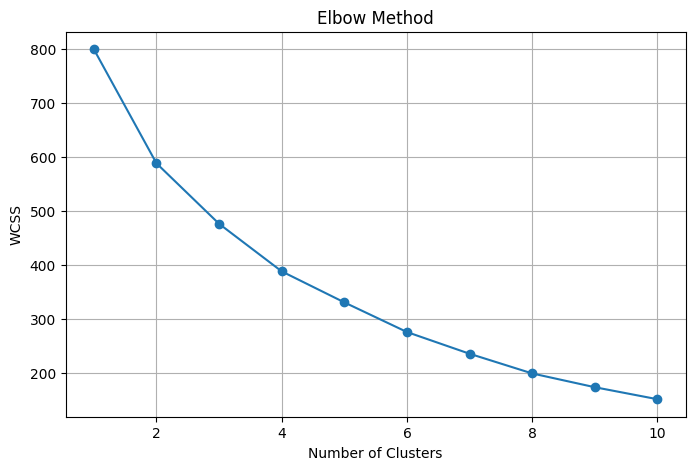


KMeans Cluster Count
KMeans_Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64


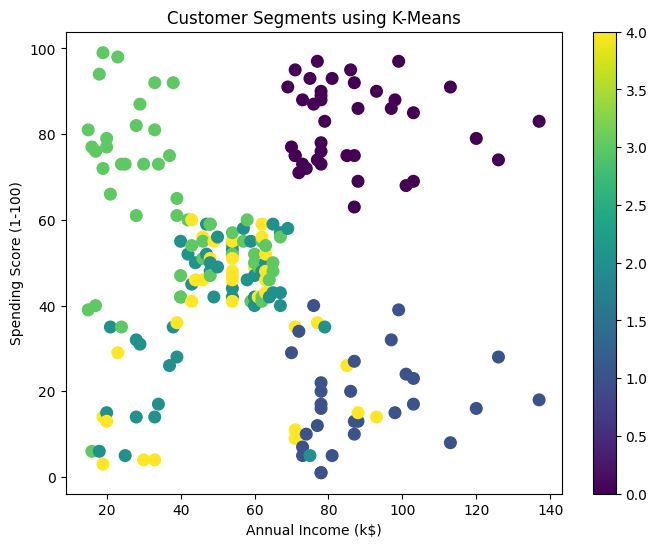

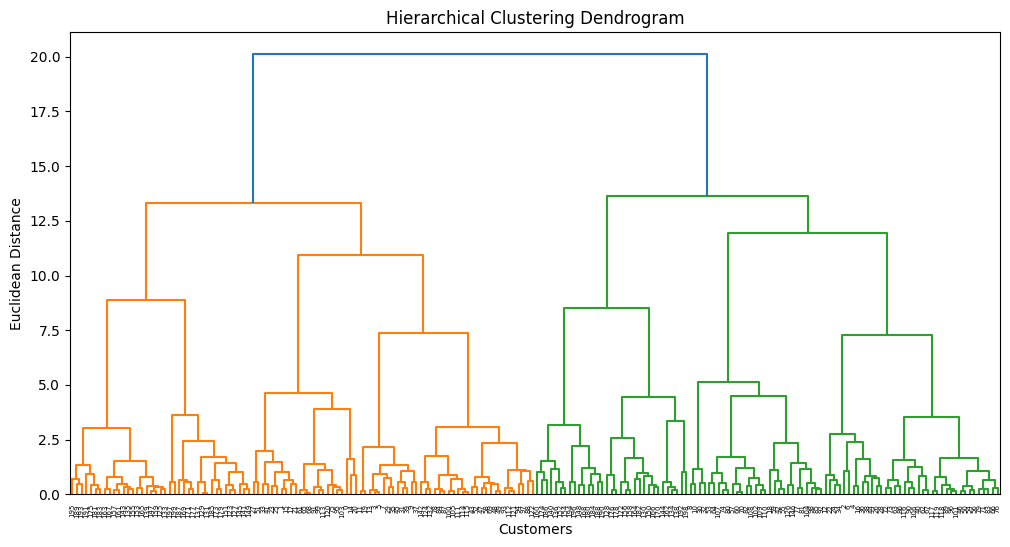


Hierarchical Cluster Count
Hierarchical_Cluster
0    61
1    39
3    38
2    33
4    29
Name: count, dtype: int64


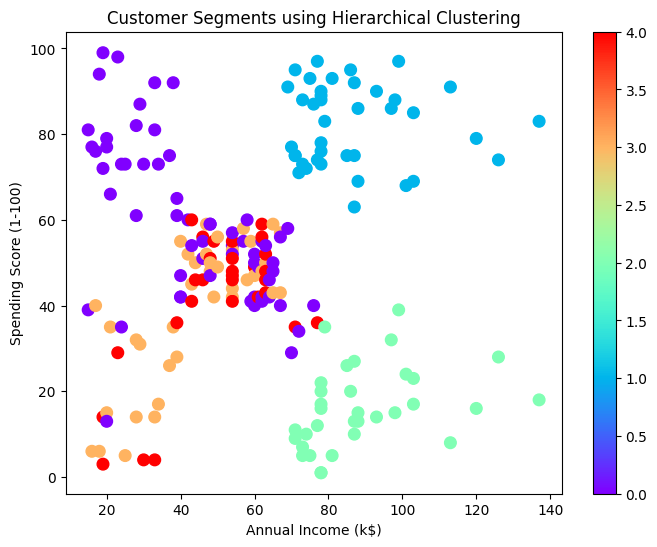


KMeans Cluster Summary
                      Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                       
0               32.692308           86.538462               82.128205
1               36.482759           89.517241               18.000000
2               49.813953           49.232558               40.069767
3               24.907407           39.722222               61.203704
4               55.714286           53.685714               36.771429

Hierarchical Cluster Summary
                            Age  Annual Income (k$)  Spending Score (1-100)
Hierarchical_Cluster                                                       
0                     26.147541           43.770492               58.967213
1                     32.692308           86.538462               82.128205
2                     41.454545           89.090909               16.181818
3                     49.789474           44.105263               39.657895


In [2]:
# ==========================================================
# CUSTOMER SEGMENTATION USING K-MEANS & HIERARCHICAL CLUSTERING
# ==========================================================

# ----------------------------
# Step 1: Import Libraries
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

# ----------------------------
# Step 2: Upload Dataset
# ----------------------------

from google.colab import files

uploaded = files.upload()

# Read Dataset
df = pd.read_csv("Mall_Customers.csv")

# ----------------------------
# Step 3: Explore Dataset
# ----------------------------

print("First Five Rows")
print(df.head())

print("\nShape:", df.shape)

print("\nInformation")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ----------------------------
# Step 4: Data Preprocessing
# ----------------------------

# Convert Gender into numeric
df["Gender"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

# Remove CustomerID
X = df.drop(columns=["CustomerID"])

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ----------------------------
# Step 5: Elbow Method
# ----------------------------

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ----------------------------
# Step 6: K-Means Clustering
# ----------------------------

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print("\nKMeans Cluster Count")
print(df["KMeans_Cluster"].value_counts())

# ----------------------------
# Step 7: KMeans Visualization
# ----------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using K-Means")

plt.colorbar()

plt.show()

# ----------------------------
# Step 8: Hierarchical Clustering
# ----------------------------

plt.figure(figsize=(12,6))

linked = linkage(
    X_scaled,
    method="ward"
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

# ----------------------------
# Step 9: Agglomerative Clustering
# ----------------------------

hc = AgglomerativeClustering(
    n_clusters=5
)

df["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

print("\nHierarchical Cluster Count")
print(df["Hierarchical_Cluster"].value_counts())

# ----------------------------
# Step 10: Hierarchical Plot
# ----------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Hierarchical_Cluster"],
    cmap="rainbow",
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using Hierarchical Clustering")

plt.colorbar()

plt.show()

# ----------------------------
# Step 11: Hidden Patterns
# ----------------------------

print("\n==============================")
print("KMeans Cluster Summary")
print("==============================")

summary = df.groupby("KMeans_Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print(summary)

print("\n==============================")
print("Hierarchical Cluster Summary")
print("==============================")

summary2 = df.groupby("Hierarchical_Cluster")[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

print(summary2)

# ----------------------------
# Step 12: Save Output
# ----------------------------

df.to_csv("Customer_Segmentation_Result.csv",index=False)

print("\nResult Saved Successfully!")

print(df.head())